# Upper Heuristic 3-gNB Baseline With Result Trace CSV

This notebook is a copy of `upper_heuristic_3gnb_baseline.ipynb` with an extra final CSV that records the start/end network state and every bias/offset decision used to produce the final demanded-PRB distribution plots.


## 1. Imports and configuration


In [1]:
import json
import importlib
import os
import sys
import warnings
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

class _MatplotlibSeabornFallback:
    def set_theme(self, *args, **kwargs):
        plt.style.use("default")

    def barplot(self, data, x, y, hue=None, dodge=True, ax=None, **kwargs):
        ax = ax or plt.gca()
        if hue is None:
            grouped = data.groupby(x, sort=False)[y].mean()
            ax.bar(range(len(grouped)), grouped.values)
            ax.set_xticks(range(len(grouped)), grouped.index)
            return ax
        pivot = data.pivot_table(index=x, columns=hue, values=y, aggfunc="mean", sort=False)
        pivot.plot(kind="bar", ax=ax, width=0.8)
        return ax

    def relplot(self, data, x, y, hue=None, col=None, style=None, kind="line", marker=None, height=3.2, aspect=1.2, facet_kws=None, **kwargs):
        cols = list(pd.unique(data[col])) if col is not None else [None]
        fig, axes = plt.subplots(1, max(len(cols), 1), figsize=(height * aspect * max(len(cols), 1), height), squeeze=False, sharey=(facet_kws or {}).get("sharey", False))
        for ax, col_value in zip(axes.flat, cols):
            sub = data if col is None else data[data[col] == col_value]
            group_cols = [c for c in (hue, style) if c is not None]
            if group_cols:
                for label, grp in sub.groupby(group_cols, sort=False):
                    label = label if isinstance(label, tuple) else (label,)
                    ax.plot(grp[x], grp[y], marker=marker or None, label=" / ".join(map(str, label)))
                ax.legend(loc="best", fontsize="small")
            else:
                ax.plot(sub[x], sub[y], marker=marker or None)
            if col is not None:
                ax.set_title(f"{col} = {col_value}")
            ax.set_xlabel(x); ax.set_ylabel(y)
        return SimpleNamespace(fig=fig, axes=axes)

    def heatmap(self, data, annot=False, fmt=".2f", center=None, vmin=None, vmax=None, cmap=None, xticklabels=None, yticklabels=None, ax=None, **kwargs):
        ax = ax or plt.gca()
        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap or "viridis", aspect="auto")
        ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if xticklabels is not None:
            ax.set_xticks(range(len(xticklabels)), xticklabels)
        if yticklabels is not None:
            ax.set_yticks(range(len(yticklabels)), yticklabels)
        if annot:
            arr = np.asarray(data)
            for i in range(arr.shape[0]):
                for j in range(arr.shape[1]):
                    ax.text(j, i, format(float(arr[i, j]), fmt), ha="center", va="center", color="black")
        return ax

if sns is None:
    sns = _MatplotlibSeabornFallback()

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "local_a3_training_env.py").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from local_a3_agent_wrapper import normalize_slice_type, quantize_a3_offset
import local_a3_training_env as local_a3_training_env_module
importlib.reload(local_a3_training_env_module)
from local_a3_training_env import UpperScenarioLowerEnv, compute_upper_expert_directional_bias
from strong_heuristic_local_executor import strong_directional_heuristic_local_executor

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)


In [2]:
CONFIG = {
    "seed": 7,
    "controlled_gnb_id": 1,
    "training_scenarios": "jain_balance_controllable,jain_control_urllc,jain_control_mmtc,jain_control_mixed",
    "scenario_selection": "cycle",
    "episode_steps": 40,
    "action_hold_steps": 5,
    "bias_hold_steps": 20,
    "max_offset_change_db": 2.0,
    "max_handovers_per_local_step": 3,
    "print_scenarios": True,
}
NUM_EPISODES = 4
OUTPUT_DIR = REPO_ROOT / "results" / "upper_heuristic_3gnb_baseline_with_trace_csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = OUTPUT_DIR / "upper_heuristic_3gnb_baseline_log.csv"
TRACE_CSV_PATH = OUTPUT_DIR / "upper_heuristic_3gnb_result_trace.csv"
DISTRIBUTION_CSV_PATH = OUTPUT_DIR / "upper_heuristic_3gnb_distribution_snapshots.csv"
GNB_IDS = (0, 1, 2)
SLICE_TYPES = ("eMBB", "URLLC", "mMTC")

# Upper heuristic total-gNB guard parameters.
SAFE_TOTAL_GNB_LOAD = 0.65
TOTAL_LOAD_GUARD_MARGIN = 0.05
MAX_DIRECTION_DELTA = 0.20


## 2. Create the 3-gNB controllable environment


In [3]:
env = UpperScenarioLowerEnv(**CONFIG)
print("action_space:", env.action_space)
print("controlled_gnb_id:", env.controlled_gnb_id)
print("neighbors:", env.neighbors)
print("slice_types:", env.slice_types)


action_space: Box(-6.0, 6.0, (6,), float32)
controlled_gnb_id: 1
neighbors: {0: (1, 2), 1: (0, 2), 2: (0, 1)}
slice_types: ('eMBB', 'URLLC', 'mMTC')


## 3. Helper functions


In [4]:
def json_safe(obj):
    if isinstance(obj, dict):
        out = {}
        for key, value in obj.items():
            out["|".join(map(str, key)) if isinstance(key, tuple) else str(key)] = json_safe(value)
        return out
    if isinstance(obj, (list, tuple)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return json_safe(obj.tolist())
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj

_warned_fallbacks = set()
def _warn_once(key, msg):
    if key not in _warned_fallbacks:
        warnings.warn(msg)
        _warned_fallbacks.add(key)

def _matrix_from_mapping(mapping, gnb_ids, slice_types, value_key=None):
    out = np.full((len(gnb_ids), len(slice_types)), np.nan, dtype=float)
    gnb_pos = {int(g): i for i, g in enumerate(gnb_ids)}
    st_pos = {normalize_slice_type(st): i for i, st in enumerate(slice_types)}
    for raw_key, raw_value in (mapping or {}).items():
        if not isinstance(raw_key, tuple) or len(raw_key) != 2:
            continue
        gid, st = int(raw_key[0]), normalize_slice_type(raw_key[1])
        if gid not in gnb_pos or st not in st_pos:
            continue
        value = raw_value
        if value_key is not None:
            if not isinstance(raw_value, dict) or value_key not in raw_value:
                continue
            value = raw_value[value_key]
        try:
            out[gnb_pos[gid], st_pos[st]] = float(value)
        except (TypeError, ValueError):
            pass
    return out

def _useful_prb_load_matrix(env, info=None):
    info = info or {}
    upper_env = getattr(env, "upper_env", None)
    if upper_env is not None and hasattr(upper_env, "_current_useful_load_matrix"):
        try:
            arr = np.asarray(upper_env._current_useful_load_matrix(), dtype=float)
            if arr.shape == (len(env.gnb_ids), len(env.slice_types)):
                return np.nan_to_num(arr, nan=0.0)
        except Exception:
            pass
    base_env = getattr(env, "base_env", None)
    if base_env is not None and hasattr(base_env, "get_window_average_slice_loads"):
        try:
            arr = _matrix_from_mapping(base_env.get_window_average_slice_loads(), env.gnb_ids, env.slice_types)
            if np.isfinite(arr).any():
                return np.nan_to_num(arr, nan=0.0)
        except Exception:
            pass
    kpis = info.get("slice_kpis", {}) if isinstance(info, dict) else {}
    return np.nan_to_num(_matrix_from_mapping(kpis, env.gnb_ids, env.slice_types, "used_load"), nan=0.0)


In [5]:
def extract_demand_prb_loads(env, info=None):
    info = info or {}
    shape = (len(env.gnb_ids), len(env.slice_types))
    upper_env = getattr(env, "upper_env", None)

    # Direct demanded PRB load: persistent per-UE upper_demand_prbs on current serving gNB.
    for method_name in ("_load_matrix", "_persistent_demand_load_matrix"):
        if upper_env is not None and hasattr(upper_env, method_name):
            try:
                arr = np.asarray(getattr(upper_env, method_name)(), dtype=float)
                if arr.shape == shape and np.isfinite(arr).any():
                    return np.nan_to_num(arr, nan=0.0), f"upper_env.{method_name}"
            except Exception:
                pass

    for key in ("demand_load_matrix_end", "demand_load_matrix_start", "demand_load_matrix", "load_matrix"):
        if key in info:
            try:
                arr = np.asarray(info[key], dtype=float)
                if arr.shape == shape and np.isfinite(arr).any():
                    return np.nan_to_num(arr, nan=0.0), f"info.{key}"
            except Exception:
                pass

    for owner_name, owner in (("base_env", getattr(env, "base_env", None)), ("upper_env", upper_env)):
        profile = getattr(owner, "_last_demand_profile", None)
        if isinstance(profile, dict):
            arr = _matrix_from_mapping(profile, env.gnb_ids, env.slice_types, "target_load")
            if np.isfinite(arr).any():
                return np.nan_to_num(arr, nan=0.0), f"{owner_name}._last_demand_profile.target_load"

    target = getattr(upper_env, "_active_target_load_matrix", None)
    if target is not None:
        try:
            arr = np.asarray(target, dtype=float)
            if arr.shape == shape and np.isfinite(arr).any():
                return np.nan_to_num(arr, nan=0.0), "upper_env._active_target_load_matrix"
        except Exception:
            pass

    base_env = getattr(env, "base_env", None)
    if base_env is not None and hasattr(base_env, "estimate_slice_load"):
        arr = np.zeros(shape, dtype=float)
        ok = False
        for gi, gid in enumerate(env.gnb_ids):
            for si, st in enumerate(env.slice_types):
                try:
                    arr[gi, si] = float(base_env.estimate_slice_load(int(gid), st)); ok = True
                except Exception:
                    pass
        if ok:
            _warn_once("estimate_slice_load", "Demand fields missing; using estimate_slice_load() fallback.")
            return arr, "base_env.estimate_slice_load"

    if base_env is not None and hasattr(base_env, "get_slice_loads"):
        try:
            arr = _matrix_from_mapping(base_env.get_slice_loads(), env.gnb_ids, env.slice_types)
            if np.isfinite(arr).any():
                _warn_once("get_slice_loads", "Demand fields missing; using get_slice_loads() fallback.")
                return np.nan_to_num(arr, nan=0.0), "base_env.get_slice_loads"
        except Exception:
            pass

    kpis = info.get("slice_kpis", {}) if isinstance(info, dict) else {}
    for value_key in ("demand_load", "requested_load", "offered_load"):
        arr = _matrix_from_mapping(kpis, env.gnb_ids, env.slice_types, value_key)
        if np.isfinite(arr).any():
            return np.nan_to_num(arr, nan=0.0), f"info.slice_kpis.{value_key}"

    for key in ("demand_prb_matrix_end", "demand_prb_matrix_start", "requested_prb_matrix", "offered_prb_matrix"):
        if key in info:
            try:
                prbs = np.asarray(info[key], dtype=float)
                if prbs.shape == shape:
                    capacities = np.array([max(float(getattr(env.base_env._get_gnb_by_id(int(gid)), "n_prbs", 0.0)), 1.0) for gid in env.gnb_ids])
                    return prbs / capacities[:, None], f"info.{key}/gnb_prbs"
            except Exception:
                pass

    _warn_once("useful_fallback", "No demanded/requested/offered load field found; falling back to useful PRB load.")
    return _useful_prb_load_matrix(env, info), "useful_prb_fallback"


In [6]:
def compute_upper_bias_for_notebook(env, demand_matrix=None):
    del demand_matrix
    return compute_upper_expert_directional_bias(
        env.base_env,
        gnb_ids=env.gnb_ids,
        neighbor_graph=env.neighbors,
        slice_types=env.slice_types,
        safe_total_gnb_load=SAFE_TOTAL_GNB_LOAD,
        total_load_guard_margin=TOTAL_LOAD_GUARD_MARGIN,
        max_direction_delta=MAX_DIRECTION_DELTA,
    )

def get_upper_expert_debug(env):
    return dict(getattr(env.base_env, "_last_upper_expert_debug", {}))


In [7]:
def _heuristic_arrays(env, load_matrix):
    all_ues = [ue for ue in env.base_env.get_all_ues() if getattr(ue, "connected", False) and getattr(ue, "serving_gnb", None) is not None]
    gnb_ids = list(env.gnb_ids)
    gnb_index = {int(gid): i for i, gid in enumerate(gnb_ids)}
    slice_index = {normalize_slice_type(st): i for i, st in enumerate(env.slice_types)}
    ue_slice = np.array([slice_index.get(normalize_slice_type(getattr(ue, "slice_type", "eMBB")), 0) for ue in all_ues], dtype=int)
    ue_serving = np.array([gnb_index.get(int(getattr(ue, "serving_gnb", 0)), 0) for ue in all_ues], dtype=int)
    rsrp = np.full((len(all_ues), len(gnb_ids)), -120.0, dtype=float)
    for u_idx, ue in enumerate(all_ues):
        for g_idx, gid in enumerate(gnb_ids):
            try:
                gnb = env.base_env._get_gnb_by_id(int(gid))
                if gnb is not None:
                    rsrp[u_idx, g_idx] = float(env.base_env._compute_link_metrics(gnb, ue).get("rx_power_dbm", -120.0))
            except Exception:
                pass
    sla_flags = env.base_env.get_slice_sla_flags() if hasattr(env.base_env, "get_slice_sla_flags") else {}
    sla = np.array([[float(sla_flags.get((int(gid), st), 0.0)) for st in env.slice_types] for gid in gnb_ids], dtype=float)
    zeros = np.zeros((len(gnb_ids), len(env.slice_types)), dtype=float)
    return gnb_ids, gnb_index, ue_slice, ue_serving, rsrp, np.asarray(load_matrix, dtype=float), sla, zeros, zeros

def compute_heuristic_action_for_gnb(env, gid, bias=None, demand_load_matrix=None, return_debug=False):
    gid = int(gid)
    local_env = env.local_envs[gid]
    if bias is None:
        bias = dict(local_env.global_bias)
    if demand_load_matrix is None:
        demand_load_matrix, _ = extract_demand_prb_loads(env)

    gnb_ids, gnb_index, ue_slice, ue_serving, rsrp, load, sla, ho_fail, pingpong = _heuristic_arrays(env, demand_load_matrix)
    g_idx = gnb_index[gid]
    max_nb = len(local_env.neighbor_ids)
    n_slices = len(env.slice_types)
    B = np.zeros((len(gnb_ids), max_nb, n_slices), dtype=float)
    for nb_slot, nb_id in enumerate(local_env.neighbor_ids):
        for s_idx, st in enumerate(env.slice_types):
            B[g_idx, nb_slot, s_idx] = float(bias.get((gid, int(nb_id), st), 0.0))

    applied = local_env.get_applied_offsets() if hasattr(local_env, "get_applied_offsets") else {}
    prev_vec = np.array([float(applied.get((int(nb), st), 0.0)) for nb in local_env.neighbor_ids for st in env.slice_types], dtype=float)
    prev_full = np.zeros_like(B, dtype=float)
    prev_full[g_idx] = prev_vec.reshape(max_nb, n_slices)
    neighbor_graph = {g_idx: [gnb_index[int(nb)] for nb in local_env.neighbor_ids]}

    offsets_full, debug = strong_directional_heuristic_local_executor(
        B=B, prev_offsets=prev_full, ue_slice=ue_slice, ue_serving_gnb=ue_serving,
        rsrp_matrix=rsrp, neighbor_graph=neighbor_graph, load=load, sla_violation=sla,
        ho_failure_ratio=ho_fail, pingpong_ratio=pingpong, slice_types=env.slice_types,
        allow_extended_negative_offsets=False,
        return_debug=True,
    )
    raw_action = offsets_full[g_idx].reshape(-1)

    # Complex mixed scenarios can produce a valid release decision whose raw
    # offset is between -1 and 0 dB. The LocalA3OffsetEnv action grid is 2 dB,
    # so nearest-neighbor quantization would turn that into 0 dB and no A3
    # candidate ever reaches the safe layer. Preserve release intent by using
    # the smallest valid release offset whenever the strong heuristic says a
    # direction/slice is an active release candidate.
    release_floor = raw_action.copy()
    flat_idx = 0
    for nb_id in local_env.neighbor_ids:
        nb_idx = gnb_index[int(nb_id)]
        for s_idx, _st in enumerate(env.slice_types):
            dbg = debug.get((g_idx, nb_idx, s_idx), {})
            release_signal = min(
                float(dbg.get("raw_offset_db", 0.0)),
                float(dbg.get("proto_offset_db", 0.0)),
            )
            if dbg.get("mode") == "release" and release_signal < -1e-9:
                release_floor[flat_idx] = -2.0
            flat_idx += 1

    limited = np.clip(release_floor - prev_vec, -float(env.max_offset_change_db), float(env.max_offset_change_db))
    action = np.array([quantize_a3_offset(float(v)) for v in prev_vec + limited], dtype=np.float32).reshape(local_env.action_space.shape)
    return (action, debug) if return_debug else action

def compute_controlled_heuristic_action(env, bias=None, demand_load_matrix=None, return_debug=False):
    return compute_heuristic_action_for_gnb(
        env,
        int(env.controlled_gnb_id),
        bias=bias,
        demand_load_matrix=demand_load_matrix,
        return_debug=return_debug,
    )


In [8]:
def _demand_dict_from_matrix(env, matrix):
    return {(int(gid), st): float(matrix[gi, si]) for gi, gid in enumerate(env.gnb_ids) for si, st in enumerate(env.slice_types)}

def _bias_dict_to_directional_tensor(env, bias):
    max_neighbors = max(len(env.neighbors[int(gid)]) for gid in env.gnb_ids)
    tensor = np.zeros((len(env.gnb_ids), max_neighbors, len(env.slice_types)), dtype=float)
    for source_id in env.gnb_ids:
        for nb_slot, target_id in enumerate(env.neighbors[int(source_id)]):
            for s_idx, st in enumerate(env.slice_types):
                tensor[int(source_id), nb_slot, s_idx] = float(bias.get((int(source_id), int(target_id), st), 0.0))
    return tensor

def _count_handover_attempts(base_env):
    return sum(len(v) for v in getattr(base_env, "_ho_attempts", {}).values())

def _count_handover_failures(base_env):
    return sum(len(v) for v in getattr(base_env, "_ho_failures", {}).values())

def _count_handover_pingpongs(base_env):
    return sum(len(v) for v in getattr(base_env, "_ho_pingpongs", {}).values())

def apply_all_heuristic_offsets(env, bias, demand_load_matrix):
    actions = {}
    debug = {}
    for gid in env.gnb_ids:
        action, gid_debug = compute_heuristic_action_for_gnb(
            env, gid, bias=bias, demand_load_matrix=demand_load_matrix, return_debug=True
        )
        actions[int(gid)] = action
        debug[int(gid)] = gid_debug
        local_env = env.local_envs[int(gid)]
        local_env._apply_proto_offsets(np.asarray(action, dtype=float).reshape(-1))
        for offset_value, (neighbor_id, slice_type) in zip(np.asarray(action, dtype=float).reshape(-1), local_env._iter_keys()):
            env.base_env.set_a3_offset(int(gid), int(neighbor_id), slice_type, float(offset_value))
    return actions, debug

def _safe_admission_totals(base_env):
    state = base_env.get_safe_admission_state() if hasattr(base_env, "get_safe_admission_state") else {}
    accepted = state.get("accepted", {}) if isinstance(state, dict) else {}
    remaining = state.get("remaining", {}) if isinstance(state, dict) else {}
    capacities = state.get("capacities", {}) if isinstance(state, dict) else {}
    return {
        "enabled": bool(state.get("enabled", False)) if isinstance(state, dict) else False,
        "accepted_total": int(sum(int(v) for v in accepted.values())) if isinstance(accepted, dict) else 0,
        "remaining_total": int(sum(int(v) for v in remaining.values())) if isinstance(remaining, dict) else 0,
        "capacity_total": int(sum(int(v) for v in capacities.values())) if isinstance(capacities, dict) else 0,
        "state": state,
    }

def step_all_heuristic(env, action, demand_load_matrix, bias=None):
    # The previous version used LocalA3OffsetEnv._execute_a3_handovers(), which bypasses safe admission.
    # This version applies all heuristic offsets, then lets MultiGNBWrapper.step(0) run safe-admitted A3 handovers.
    if bias is None:
        bias = dict(env.local_envs[int(env.controlled_gnb_id)].global_bias)

    actions, action_debug = apply_all_heuristic_offsets(env, bias, demand_load_matrix)
    base_env = env.base_env
    demand_dict = _demand_dict_from_matrix(env, demand_load_matrix)
    previous_provider = getattr(base_env, "safe_admission_load_provider", None)
    start_events = len(getattr(base_env, "handover_events", []))
    start_attempts = _count_handover_attempts(base_env)
    start_failures = _count_handover_failures(base_env)
    start_pingpongs = _count_handover_pingpongs(base_env)

    try:
        base_env.safe_admission_load_provider = lambda gid, st: float(demand_dict.get((int(gid), normalize_slice_type(st)), 0.0))
        base_env.begin_safe_admission_window(_bias_dict_to_directional_tensor(env, bias), env.slice_types)
        base_env.begin_radio_measurement_window()
        base_env.begin_sla_window()
        _base_obs, base_reward, terminated, truncated, base_info = base_env.step(0)
    finally:
        base_env.safe_admission_load_provider = previous_provider

    end_events = len(getattr(base_env, "handover_events", []))
    handover_stats = {
        "attempts": int(_count_handover_attempts(base_env) - start_attempts),
        "successes": int(end_events - start_events),
        "failures": int(_count_handover_failures(base_env) - start_failures),
        "ping_pongs": int(_count_handover_pingpongs(base_env) - start_pingpongs),
    }

    controlled_action = np.asarray(action, dtype=float).reshape(-1)
    local_reward = env._ctrl_env._compute_local_reward(controlled_action, handover_stats)
    obs = env._ctrl_env._build_observation()
    info = env._ctrl_env._build_info(base_info=base_info, handover_stats=handover_stats)
    safe_totals = _safe_admission_totals(base_env)
    info["safe_admission"] = safe_totals["state"]
    info["safe_admission_enabled"] = safe_totals["enabled"]
    info["safe_admission_accepted_total"] = safe_totals["accepted_total"]
    info["safe_admission_remaining_total"] = safe_totals["remaining_total"]
    info["safe_admission_capacity_total"] = safe_totals["capacity_total"]
    info["all_heuristic_actions"] = actions
    info["all_heuristic_action_debug"] = action_debug
    info["scenario_name"] = getattr(env, "_current_scenario_name", "unknown")

    env._elapsed_steps += 1
    truncated = bool(truncated or env._elapsed_steps >= env.episode_steps)
    return obs, float(local_reward + float(base_reward)), bool(terminated), bool(truncated), info


In [9]:
def _safe_info_value(info, names, default=0.0):
    for name in names:
        if isinstance(info, dict) and name in info and np.isscalar(info[name]):
            try: return float(info[name])
            except (TypeError, ValueError): pass
    return default

def _handover_stats(info):
    stats = dict(info.get("handover_stats", {})) if isinstance(info, dict) and isinstance(info.get("handover_stats"), dict) else {}
    attempts = float(stats.get("attempts", _safe_info_value(info, ["handover_attempts", "handover_attempt_count"], 0.0)))
    successes = float(stats.get("successes", _safe_info_value(info, ["handover_count", "handovers", "num_handovers", "accepted_handovers", "handover_successes", "total_handovers"], 0.0)))
    failures = float(stats.get("failures", _safe_info_value(info, ["handover_failures"], 0.0)))
    ping_pongs = float(stats.get("ping_pongs", _safe_info_value(info, ["handover_ping_pongs", "ping_pongs"], 0.0)))
    if successes == 0.0:
        total, found = 0.0, False
        for key, val in (info or {}).items():
            if "handover" in str(key).lower() and np.isscalar(val):
                try: total += float(val); found = True
                except (TypeError, ValueError): pass
        if found:
            successes = total
    return {"attempts": attempts, "successes": successes, "failures": failures, "ping_pongs": ping_pongs}

def _handover_count(info):
    return _handover_stats(info)["successes"]

def log_step_metrics(env, episode, step, scenario_name, reward, done, info, action, bias, demand_source):
    demand_matrix, source = extract_demand_prb_loads(env, info)
    useful_matrix = _useful_prb_load_matrix(env, info)
    ho = _handover_stats(info)
    row = {
        "episode": int(episode), "step": int(step), "scenario_name": str(scenario_name),
        "reward": float(reward), "done": bool(done), "handover_count": float(ho["successes"]),
        "handover_attempts": float(ho["attempts"]), "handover_failures": float(ho["failures"]),
        "handover_ping_pongs": float(ho["ping_pongs"]),
        "safe_admission_enabled": bool(info.get("safe_admission_enabled", False)),
        "safe_admission_accepted_total": int(info.get("safe_admission_accepted_total", 0)),
        "safe_admission_remaining_total": int(info.get("safe_admission_remaining_total", 0)),
        "safe_admission_capacity_total": int(info.get("safe_admission_capacity_total", 0)),
        "safe_admission_json": json.dumps(json_safe(info.get("safe_admission", {})), sort_keys=True),
        "safe_total_gnb_load": float(SAFE_TOTAL_GNB_LOAD),
        "total_load_guard_margin": float(TOTAL_LOAD_GUARD_MARGIN),
        "max_direction_delta": float(MAX_DIRECTION_DELTA),
        "upper_expert_debug_json": json.dumps(json_safe(get_upper_expert_debug(env)), sort_keys=True),
        "rejected_target_total_high_count": int(len(get_upper_expert_debug(env).get("rejected_target_total_high", []))),
        "demand_load_source": str(source or demand_source),
        "upper_bias_json": json.dumps(json_safe(bias), sort_keys=True),
    }
    for gi, gid in enumerate(env.gnb_ids):
        row[f"demand_prb_load_g{gid}"] = float(np.sum(demand_matrix[gi, :]))
        row[f"useful_load_g{gid}"] = float(np.sum(useful_matrix[gi, :]))
        for si, st in enumerate(env.slice_types):
            row[f"demand_prb_load_g{gid}_{st}"] = float(demand_matrix[gi, si])
            row[f"useful_load_g{gid}_{st}"] = float(useful_matrix[gi, si])
    action_vec = np.asarray(action, dtype=float).reshape(-1)
    controlled_env = env.local_envs[int(env.controlled_gnb_id)]
    for idx, (neighbor_id, slice_type) in enumerate(controlled_env._iter_keys()):
        row[f"action_offset_g{env.controlled_gnb_id}_to_g{neighbor_id}_{slice_type}"] = float(action_vec[idx])
    return row


In [10]:
def _finite_or_nan(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan

def _mean_or_nan(values):
    values = [_finite_or_nan(v) for v in values]
    values = [v for v in values if np.isfinite(v)]
    return float(np.mean(values)) if values else np.nan

def capture_network_state_rows(env, episode, scenario_name, snapshot, step, cumulative_handovers, info=None):
    """Long-format state snapshot: demand/useful load plus UE serving state per gNB/slice."""
    demand_matrix, demand_source = extract_demand_prb_loads(env, info or {})
    useful_matrix = _useful_prb_load_matrix(env, info or {})
    rows = []
    all_ues = [ue for ue in env.base_env.get_all_ues() if getattr(ue, "connected", False)]
    for gi, gid in enumerate(env.gnb_ids):
        for slice_type in ("TOTAL", *env.slice_types):
            if slice_type == "TOTAL":
                selected = [ue for ue in all_ues if getattr(ue, "serving_gnb", None) is not None and int(ue.serving_gnb) == int(gid)]
                demand_load = float(np.sum(demand_matrix[gi, :]))
                useful_load = float(np.sum(useful_matrix[gi, :]))
            else:
                selected = [
                    ue for ue in all_ues
                    if getattr(ue, "serving_gnb", None) is not None
                    and int(ue.serving_gnb) == int(gid)
                    and normalize_slice_type(getattr(ue, "slice_type", "eMBB")) == normalize_slice_type(slice_type)
                ]
                si = list(env.slice_types).index(slice_type)
                demand_load = float(demand_matrix[gi, si])
                useful_load = float(useful_matrix[gi, si])
            rows.append({
                "record_type": "network_state",
                "episode": int(episode),
                "scenario_name": str(scenario_name),
                "snapshot": str(snapshot),
                "step": int(step),
                "cumulative_handovers": float(cumulative_handovers),
                "gnb": int(gid),
                "slice_type": str(slice_type),
                "demand_prb_load": demand_load,
                "useful_load": useful_load,
                "ue_count": int(len(selected)),
                "ue_ids_json": json.dumps([int(getattr(ue, "id", -1)) for ue in selected]),
                "ue_demand_prbs_total": float(sum(max(float(getattr(ue, "upper_demand_prbs", 0.0)), 0.0) for ue in selected)),
                "ue_x_mean": _mean_or_nan(getattr(ue, "x", np.nan) for ue in selected),
                "ue_y_mean": _mean_or_nan(getattr(ue, "y", np.nan) for ue in selected),
                "demand_load_source": str(demand_source),
            })
    return rows

def capture_bias_offset_rows(env, episode, scenario_name, step, bias, info):
    """One row per source-gNB/neighbor/slice decision at a step."""
    actions = info.get("all_heuristic_actions", {}) if isinstance(info, dict) else {}
    action_debug = info.get("all_heuristic_action_debug", {}) if isinstance(info, dict) else {}
    gnb_index = {int(gid): i for i, gid in enumerate(env.gnb_ids)}
    rows = []
    for source_gnb in env.gnb_ids:
        source_gnb = int(source_gnb)
        local_env = env.local_envs[source_gnb]
        raw_action = actions.get(source_gnb)
        if raw_action is None:
            applied = local_env.get_applied_offsets() if hasattr(local_env, "get_applied_offsets") else {}
            action_vec = np.array([float(applied.get((int(nb), st), 0.0)) for nb in local_env.neighbor_ids for st in env.slice_types], dtype=float)
        else:
            action_vec = np.asarray(raw_action, dtype=float).reshape(-1)
        gid_debug = action_debug.get(source_gnb, {}) if isinstance(action_debug, dict) else {}
        for idx, (target_gnb, slice_type) in enumerate(local_env._iter_keys()):
            target_gnb = int(target_gnb)
            slice_type = normalize_slice_type(slice_type)
            s_idx = list(env.slice_types).index(slice_type)
            debug_key = (gnb_index[source_gnb], gnb_index[target_gnb], s_idx)
            debug = gid_debug.get(debug_key, {}) if isinstance(gid_debug, dict) else {}
            rows.append({
                "record_type": "bias_offset_decision",
                "episode": int(episode),
                "scenario_name": str(scenario_name),
                "snapshot": "step_decision",
                "step": int(step),
                "source_gnb": source_gnb,
                "target_gnb": target_gnb,
                "slice_type": slice_type,
                "upper_bias": float(bias.get((source_gnb, target_gnb, slice_type), 0.0)),
                "offset_db": float(action_vec[idx]),
                "heuristic_mode": str(debug.get("mode", "")),
                "raw_offset_db": _finite_or_nan(debug.get("raw_offset_db", np.nan)),
                "proto_offset_db": _finite_or_nan(debug.get("proto_offset_db", np.nan)),
                "safe_admission_accepted_total": int(info.get("safe_admission_accepted_total", 0)) if isinstance(info, dict) else 0,
                "safe_admission_remaining_total": int(info.get("safe_admission_remaining_total", 0)) if isinstance(info, dict) else 0,
                "handover_count": float(_handover_stats(info).get("successes", 0.0)) if isinstance(info, dict) else 0.0,
                "upper_bias_json": json.dumps(json_safe(bias), sort_keys=True),
            })
    return rows


## 4. Run heuristic baseline episodes


In [11]:
rows, episode_returns, episode_handover_counts = [], [], []
network_state_rows, bias_offset_rows = [], []

for episode in range(NUM_EPISODES):
    obs, reset_info = env.reset(seed=CONFIG["seed"] + episode)
    scenario_name = getattr(env, "_current_scenario_name", reset_info.get("scenario_name", "unknown"))
    ep_return, ep_handovers = 0.0, 0.0
    last_step = -1

    network_state_rows.extend(capture_network_state_rows(
        env, episode, scenario_name, snapshot="start", step=-1, cumulative_handovers=0.0, info=reset_info
    ))

    for step in range(CONFIG["episode_steps"]):
        demand_matrix, demand_source = extract_demand_prb_loads(env, reset_info if step == 0 else {})
        bias = compute_upper_bias_for_notebook(env, demand_matrix)
        for local_env in env.local_envs.values():
            local_env.set_global_bias(bias)
        action, action_debug = compute_controlled_heuristic_action(env, bias=bias, demand_load_matrix=demand_matrix, return_debug=True)
        obs, reward, terminated, truncated, info = step_all_heuristic(env, action, demand_matrix, bias=bias)
        done = bool(terminated or truncated)
        row = log_step_metrics(env, episode, step, scenario_name, reward, done, info, action, bias, demand_source)
        row["controlled_action_debug_json"] = json.dumps(json_safe(action_debug), sort_keys=True)
        rows.append(row)
        bias_offset_rows.extend(capture_bias_offset_rows(env, episode, scenario_name, step, bias, info))
        ep_return += float(reward)
        ep_handovers += float(row["handover_count"])
        last_step = step
        if done:
            break

    network_state_rows.extend(capture_network_state_rows(
        env, episode, scenario_name, snapshot="end", step=last_step, cumulative_handovers=ep_handovers, info=info if rows else reset_info
    ))
    episode_returns.append({"episode": episode, "scenario_name": scenario_name, "episode_return": ep_return})
    episode_handover_counts.append({"episode": episode, "scenario_name": scenario_name, "handover_count": ep_handovers})
    print(f"episode={episode} scenario={scenario_name} return={ep_return:.3f} handovers={ep_handovers:.0f}")

df = pd.DataFrame(rows)
episode_df = pd.DataFrame(episode_returns)
episode_ho_df = pd.DataFrame(episode_handover_counts)
network_state_df = pd.DataFrame(network_state_rows)
bias_offset_df = pd.DataFrame(bias_offset_rows)
trace_df = pd.concat([network_state_df, bias_offset_df], ignore_index=True, sort=False)
display(df.head())
display(trace_df.head())


[UpperScenarioLowerEnv] reset=1 controlled_gnb=1 scenario=jain_balance_controllable
episode=0 scenario=jain_balance_controllable return=-8.579 handovers=5
[UpperScenarioLowerEnv] reset=2 controlled_gnb=1 scenario=jain_control_urllc
episode=1 scenario=jain_control_urllc return=-13.622 handovers=3
[UpperScenarioLowerEnv] reset=3 controlled_gnb=1 scenario=jain_control_mmtc
episode=2 scenario=jain_control_mmtc return=-11.714 handovers=0
[UpperScenarioLowerEnv] reset=4 controlled_gnb=1 scenario=jain_control_mixed
episode=3 scenario=jain_control_mixed return=-61.174 handovers=15


,episode,step,scenario_name,reward,done,handover_count,handover_attempts,handover_failures,handover_ping_pongs,safe_admission_enabled,...,useful_load_g2_URLLC,demand_prb_load_g2_mMTC,useful_load_g2_mMTC,action_offset_g1_to_g0_eMBB,action_offset_g1_to_g0_URLLC,action_offset_g1_to_g0_mMTC,action_offset_g1_to_g2_eMBB,action_offset_g1_to_g2_URLLC,action_offset_g1_to_g2_mMTC,controlled_action_debug_json
0,0,0,jain_balance_controllable,-0.669444,False,0.0,0.0,0.0,0.0,True,...,0.0,0.0,0.0,-2.0,0.0,0.0,-2.0,0.0,0.0,"{""1|0|0"": {""applied_offset_db"": -4.0, ""best_ra..."
1,0,1,jain_balance_controllable,-0.666667,False,0.0,0.0,0.0,0.0,True,...,0.0,0.0,0.0,-2.0,0.0,0.0,-2.0,0.0,0.0,"{""1|0|0"": {""applied_offset_db"": -4.0, ""best_ra..."
2,0,2,jain_balance_controllable,-0.180684,False,3.0,3.0,0.0,0.0,True,...,0.0,0.0,0.0,-2.0,0.0,0.0,-2.0,0.0,0.0,"{""1|0|0"": {""applied_offset_db"": -4.0, ""best_ra..."
3,0,3,jain_balance_controllable,-0.167113,False,0.0,0.0,0.0,0.0,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"{""1|0|0"": {""applied_offset_db"": 0.0, ""best_rad..."
4,0,4,jain_balance_controllable,-0.180676,False,0.0,0.0,0.0,0.0,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"{""1|0|0"": {""applied_offset_db"": 0.0, ""best_rad..."


,record_type,episode,scenario_name,snapshot,step,cumulative_handovers,gnb,slice_type,demand_prb_load,useful_load,...,target_gnb,upper_bias,offset_db,heuristic_mode,raw_offset_db,proto_offset_db,safe_admission_accepted_total,safe_admission_remaining_total,handover_count,upper_bias_json
0,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,TOTAL,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,eMBB,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,URLLC,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,mMTC,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,network_state,0,jain_balance_controllable,start,-1,0.0,1.0,TOTAL,0.9,0.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Save CSV log


In [12]:
df.to_csv(CSV_PATH, index=False)
trace_df.to_csv(TRACE_CSV_PATH, index=False)
print(f"saved {len(df)} step rows to {CSV_PATH}")
print(f"saved {len(trace_df)} trace rows to {TRACE_CSV_PATH}")
print("step-log columns:", len(df.columns))
print("trace columns:", len(trace_df.columns))


saved 160 step rows to /home/oussama/Desktop/chech/results/upper_heuristic_3gnb_baseline_with_trace_csv/upper_heuristic_3gnb_baseline_log.csv
saved 2976 trace rows to /home/oussama/Desktop/chech/results/upper_heuristic_3gnb_baseline_with_trace_csv/upper_heuristic_3gnb_result_trace.csv
step-log columns: 52
trace columns: 27


## 6. Plot results


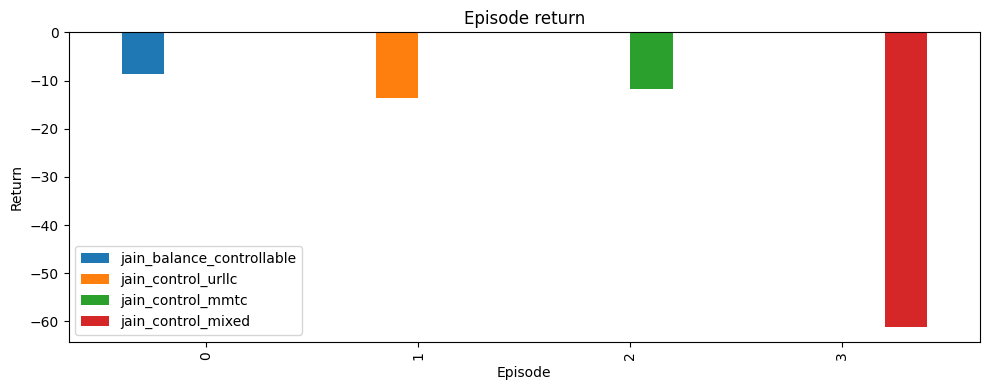

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=episode_df, x="episode", y="episode_return", hue="scenario_name", dodge=False, ax=ax)
ax.set_title("Episode return"); ax.set_xlabel("Episode"); ax.set_ylabel("Return")
ax.legend(loc="best"); plt.tight_layout()


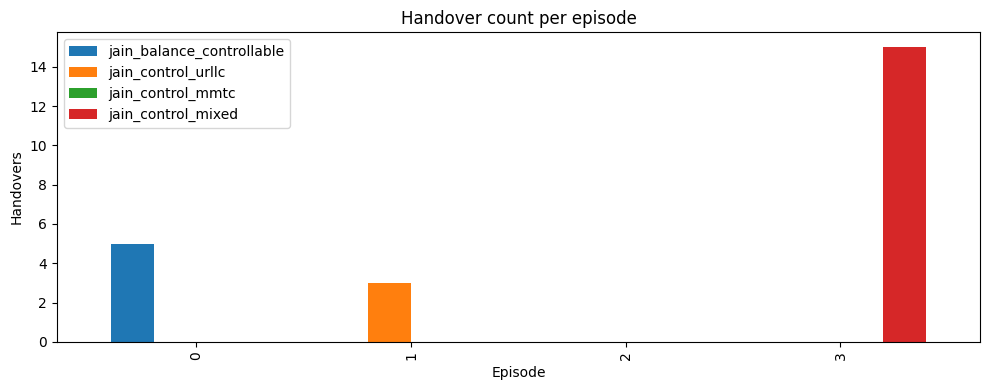

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=episode_ho_df, x="episode", y="handover_count", hue="scenario_name", dodge=False, ax=ax)
ax.set_title("Handover count per episode"); ax.set_xlabel("Episode"); ax.set_ylabel("Handovers")
ax.legend(loc="best"); plt.tight_layout()


## Safe-admission diagnostics

These checks verify that handovers are going through the `MultiGNBWrapper` safe-admission path, not the direct local handover shortcut.


,episode,scenario_name,step,handover_count,handover_attempts,safe_admission_enabled,safe_admission_accepted_total,safe_admission_remaining_total,safe_admission_capacity_total
0,0,jain_balance_controllable,0,0.0,0.0,True,0,6,6
1,0,jain_balance_controllable,1,0.0,0.0,True,0,6,6
2,0,jain_balance_controllable,2,3.0,3.0,True,3,3,6
3,0,jain_balance_controllable,3,0.0,0.0,True,0,4,4
4,0,jain_balance_controllable,4,0.0,0.0,True,0,4,4
5,0,jain_balance_controllable,5,0.0,0.0,True,0,4,4
6,0,jain_balance_controllable,6,0.0,0.0,True,0,4,4
7,0,jain_balance_controllable,7,0.0,0.0,True,0,4,4
8,0,jain_balance_controllable,8,0.0,0.0,True,0,4,4
9,0,jain_balance_controllable,9,0.0,0.0,True,0,4,4


,episode,scenario_name,total_handovers,total_attempts,safe_enabled,max_step_handovers,max_safe_accepted
0,0,jain_balance_controllable,5.0,5.0,True,3.0,3
1,1,jain_control_urllc,3.0,3.0,True,3.0,3
2,2,jain_control_mmtc,0.0,0.0,True,0.0,0
3,3,jain_control_mixed,15.0,15.0,True,3.0,3


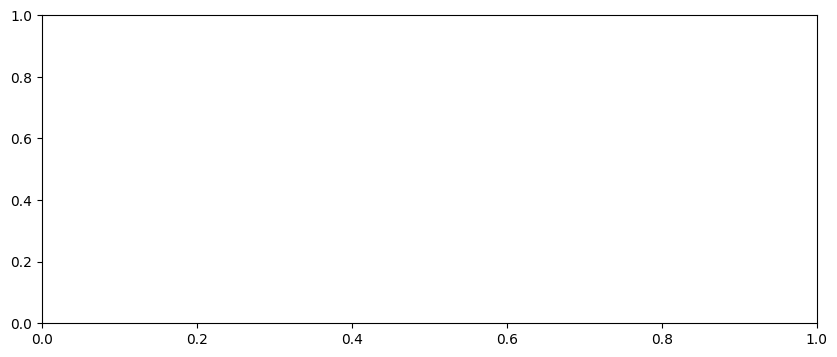

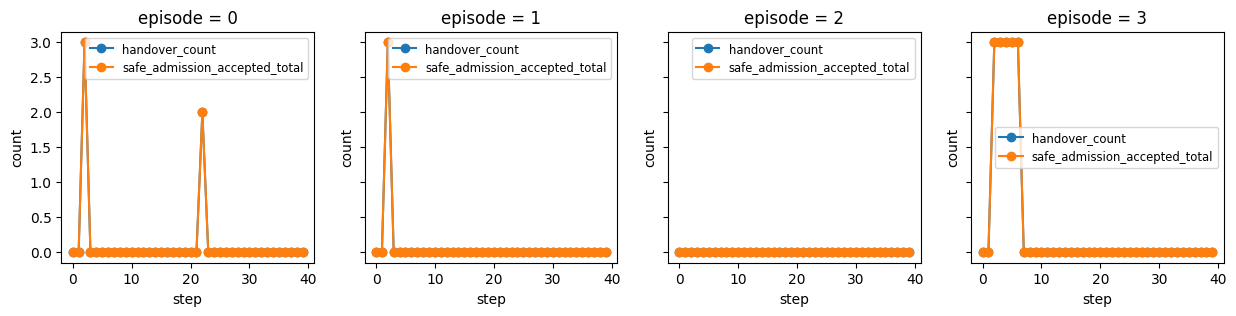

In [15]:
safe_cols = [
    "episode", "scenario_name", "step", "handover_count", "handover_attempts",
    "safe_admission_enabled", "safe_admission_accepted_total",
    "safe_admission_remaining_total", "safe_admission_capacity_total",
]
existing_safe_cols = [c for c in safe_cols if c in df.columns]
display(df[existing_safe_cols].head(20))

safe_episode = df.groupby(["episode", "scenario_name"], sort=False).agg(
    total_handovers=("handover_count", "sum"),
    total_attempts=("handover_attempts", "sum"),
    safe_enabled=("safe_admission_enabled", "max"),
    max_step_handovers=("handover_count", "max"),
    max_safe_accepted=("safe_admission_accepted_total", "max"),
).reset_index()
display(safe_episode)

fig, ax = plt.subplots(figsize=(10, 4))
safe_plot = df.melt(
    id_vars=["episode", "step", "scenario_name"],
    value_vars=["handover_count", "safe_admission_accepted_total"],
    var_name="metric",
    value_name="count",
)
sns.relplot(
    data=safe_plot,
    x="step",
    y="count",
    hue="metric",
    col="episode",
    kind="line",
    marker="o",
    height=3.0,
    aspect=1.25,
    facet_kws={"sharey": True},
)
plt.show()


## Rejected target-total-load directions

Directions listed here were prevented from receiving negative bias because the target gNB total demanded load had too little headroom.


In [16]:
def _extract_target_total_rejections(df):
    rows = []
    for _, row in df.iterrows():
        try:
            debug = json.loads(row.get("upper_expert_debug_json", "{}"))
        except Exception:
            debug = {}
        for item in debug.get("rejected_target_total_high", []):
            rows.append({
                "episode": int(row["episode"]),
                "step": int(row["step"]),
                "scenario_name": row["scenario_name"],
                "source_id": int(item.get("source_id", -1)),
                "target_id": int(item.get("target_id", -1)),
                "slice_type": item.get("slice_type", "unknown"),
                "reason": item.get("reason", "unknown"),
                "target_total_load": float(item.get("target_total_load", np.nan)),
                "target_total_headroom": float(item.get("target_total_headroom", np.nan)),
                "estimated_delta": float(item.get("estimated_delta", np.nan)),
            })
    return pd.DataFrame(rows)

target_total_rejections = _extract_target_total_rejections(df)
display(target_total_rejections.head(30))

if len(target_total_rejections):
    summary = target_total_rejections.groupby(
        ["episode", "scenario_name", "target_id", "slice_type", "reason"],
        sort=False,
    ).size().reset_index(name="count")
    display(summary)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=summary, x="target_id", y="count", hue="slice_type", ax=ax)
    ax.set_title("Rejected candidate directions because target total gNB load was too high")
    ax.set_xlabel("target gNB")
    ax.set_ylabel("rejected directions")
    plt.tight_layout()
else:
    print("No target-total-load rejections logged in this run.")


""


No target-total-load rejections logged in this run.


Text(0.5, 1.05, 'Demanded PRB load per gNB over time')

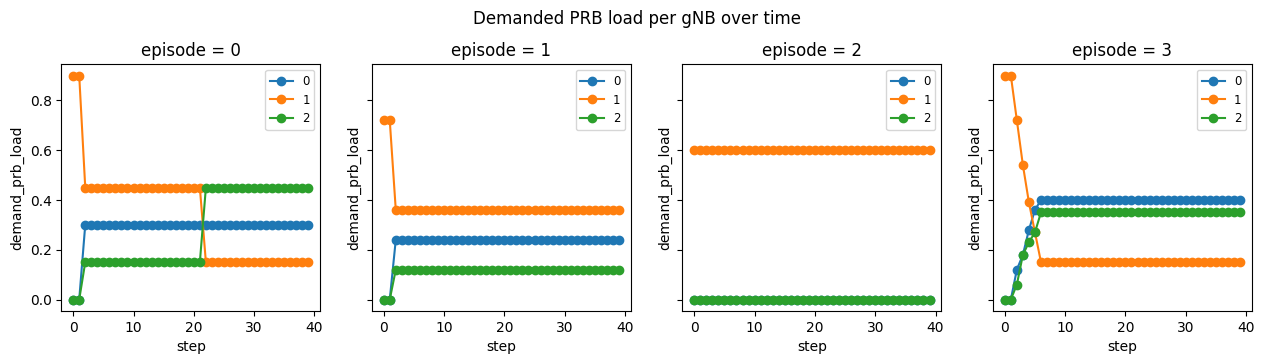

In [17]:
demand_total_cols = [f"demand_prb_load_g{gid}" for gid in GNB_IDS if f"demand_prb_load_g{gid}" in df.columns]
plot_df = df.melt(id_vars=["episode", "step", "scenario_name"], value_vars=demand_total_cols, var_name="gnb", value_name="demand_prb_load")
plot_df["gnb"] = plot_df["gnb"].str.extract(r"g(\d+)").astype(int)
g = sns.relplot(data=plot_df, x="step", y="demand_prb_load", hue="gnb", col="episode", kind="line", marker="o", height=3.2, aspect=1.2, facet_kws={"sharey": True})
g.fig.suptitle("Demanded PRB load per gNB over time", y=1.05)


Text(0.5, 1.05, 'Demanded PRB load per gNB/slice over time')

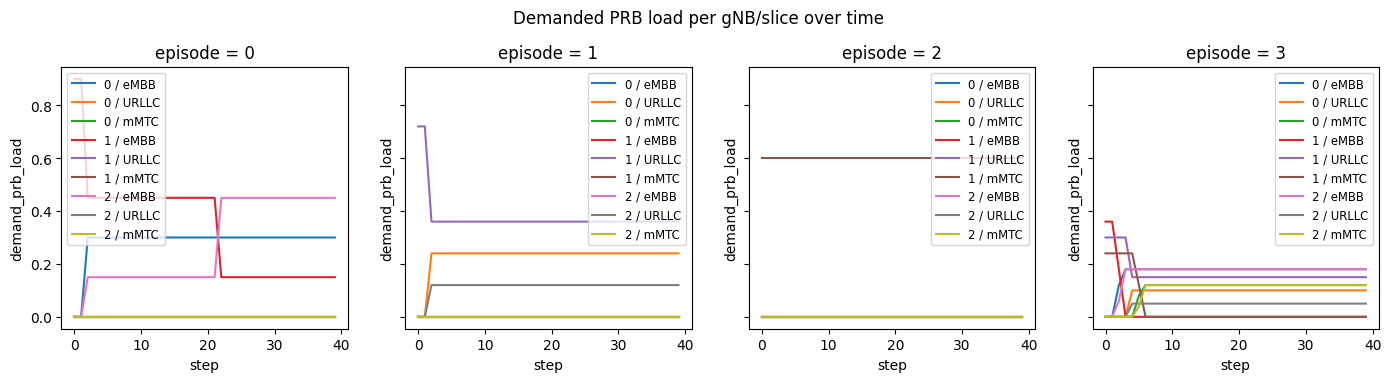

In [18]:
demand_slice_cols = [f"demand_prb_load_g{gid}_{st}" for gid in GNB_IDS for st in SLICE_TYPES if f"demand_prb_load_g{gid}_{st}" in df.columns]
slice_df = df.melt(id_vars=["episode", "step", "scenario_name"], value_vars=demand_slice_cols, var_name="metric", value_name="demand_prb_load")
slice_df[["gnb", "slice_type"]] = slice_df["metric"].str.extract(r"g(\d+)_(.+)$")
slice_df["gnb"] = slice_df["gnb"].astype(int)
g = sns.relplot(data=slice_df, x="step", y="demand_prb_load", hue="gnb", style="slice_type", col="episode", kind="line", height=3.4, aspect=1.25, facet_kws={"sharey": True})
g.fig.suptitle("Demanded PRB load per gNB/slice over time", y=1.05)


## Demanded PRB distribution after handover

This table and plot show the demanded PRB load distribution immediately after the first successful handover in each episode. If an episode has no logged handover, it uses the final row as a fallback.


gnb,episode,scenario_name,snapshot,step,cumulative_handovers,gNB0,gNB1,gNB2
0,0,jain_balance_controllable,after_first_handover,2,3.0,0.30,0.45,0.15
1,0,jain_balance_controllable,after_last_handover,22,5.0,0.30,0.15,0.45
2,0,jain_balance_controllable,final,39,5.0,0.30,0.15,0.45
3,1,jain_control_urllc,after_first_handover,2,3.0,0.24,0.36,0.12
4,1,jain_control_urllc,after_last_handover,2,3.0,0.24,0.36,0.12
5,1,jain_control_urllc,final,39,3.0,0.24,0.36,0.12
6,2,jain_control_mmtc,final,39,0.0,0.00,0.60,0.00
7,3,jain_control_mixed,after_first_handover,2,3.0,0.12,0.72,0.06
8,3,jain_control_mixed,after_last_handover,6,15.0,0.40,0.15,0.35
9,3,jain_control_mixed,final,39,15.0,0.40,0.15,0.35


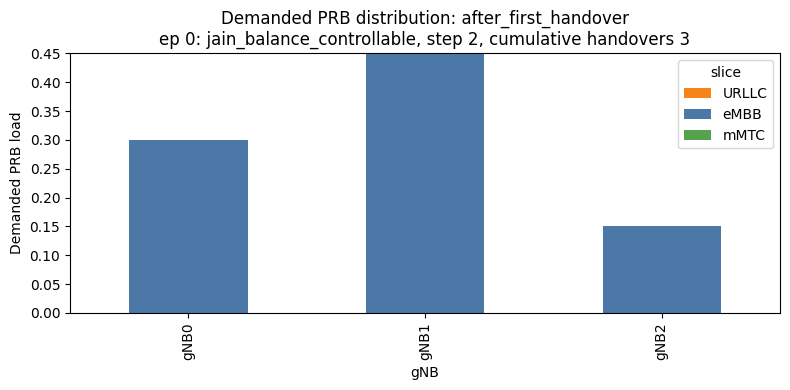

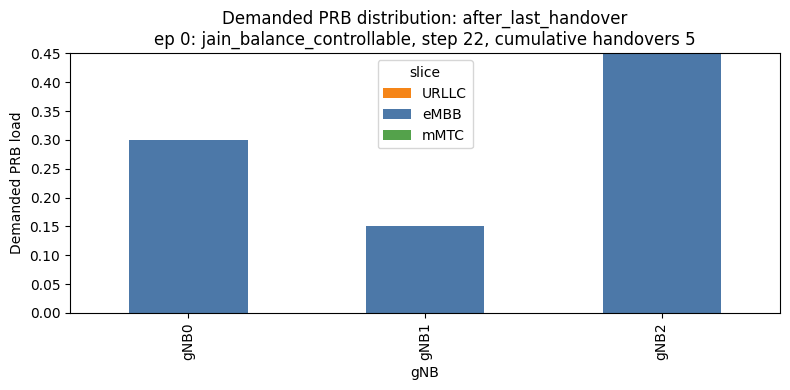

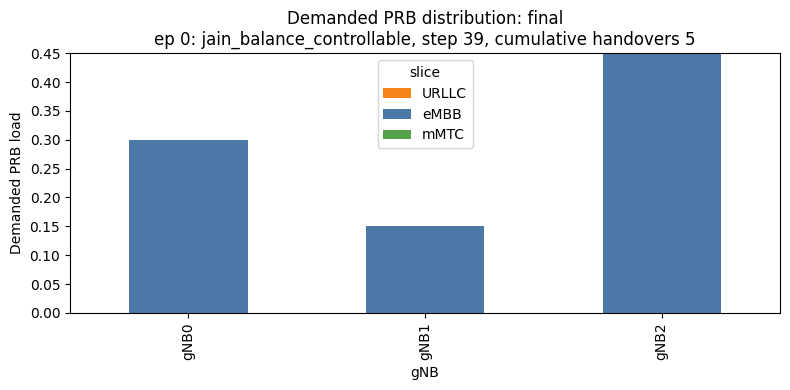

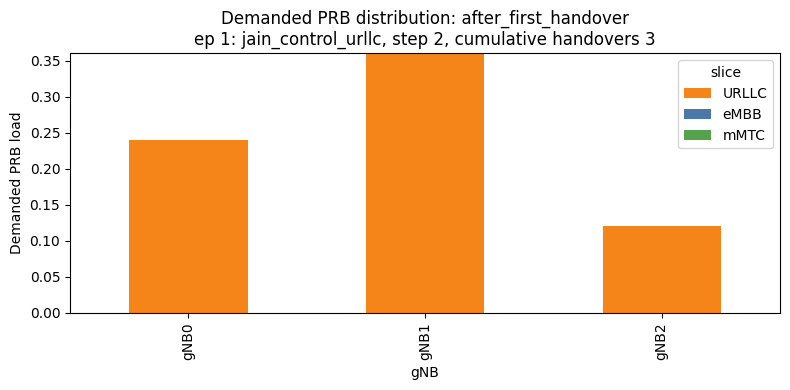

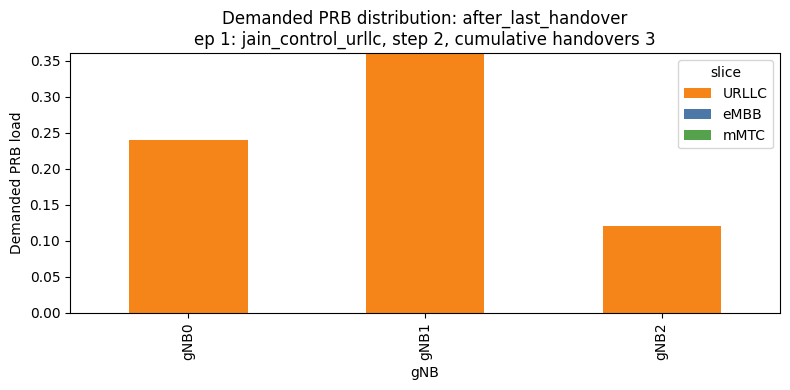

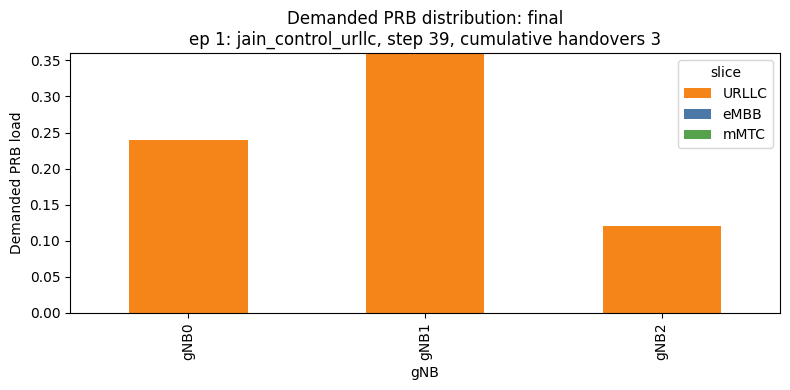

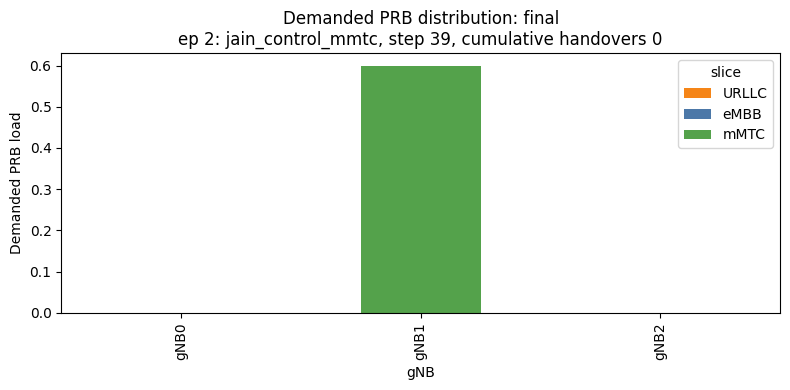

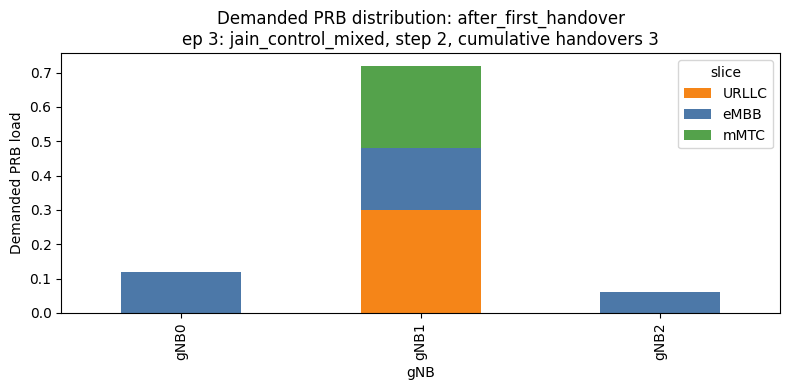

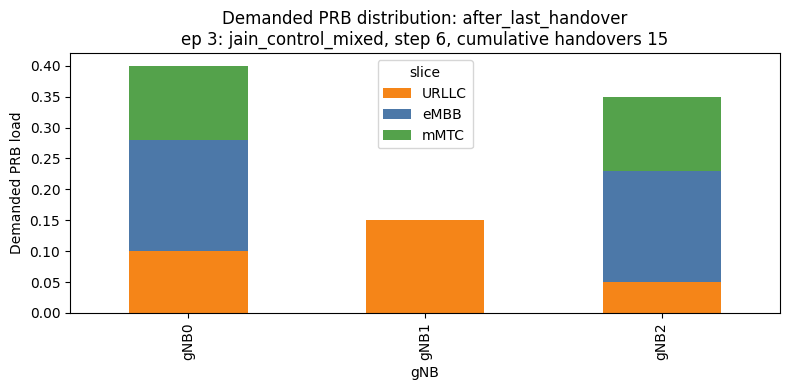

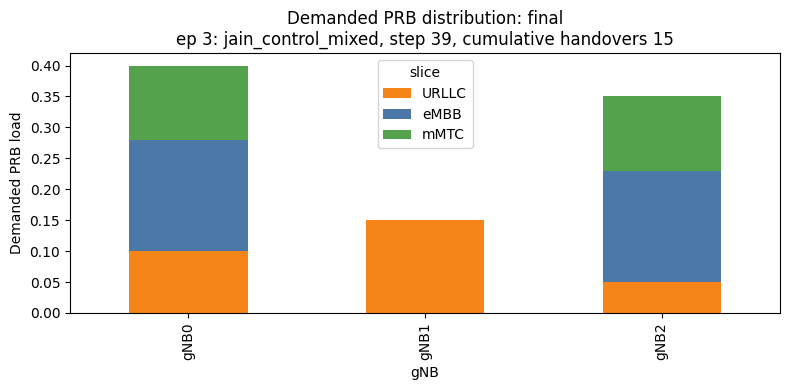

In [19]:
def _demand_distribution_rows(df):
    rows = []
    for (episode, scenario), group in df.groupby(["episode", "scenario_name"], sort=False):
        group = group.sort_values("step").copy()
        group["cumulative_handovers"] = group["handover_count"].fillna(0.0).cumsum()
        handover_rows = group[group["handover_count"].fillna(0.0) > 0.0]
        snapshots = []
        if len(handover_rows):
            snapshots.append(("after_first_handover", handover_rows.iloc[0]))
            snapshots.append(("after_last_handover", handover_rows.iloc[-1]))
        snapshots.append(("final", group.iloc[-1]))

        seen = set()
        for label, selected in snapshots:
            key = (label, int(selected["step"]))
            if key in seen:
                continue
            seen.add(key)
            for gid in GNB_IDS:
                total_col = f"demand_prb_load_g{gid}"
                if total_col not in group.columns:
                    continue
                base = {
                    "episode": int(episode),
                    "scenario_name": scenario,
                    "snapshot": label,
                    "step": int(selected["step"]),
                    "gnb": int(gid),
                    "slice_type": "TOTAL",
                    "demand_prb_load": float(selected[total_col]),
                    "cumulative_handovers": float(selected["cumulative_handovers"]),
                }
                rows.append(base)
                for st in SLICE_TYPES:
                    col = f"demand_prb_load_g{gid}_{st}"
                    if col in group.columns:
                        rows.append({**base, "slice_type": st, "demand_prb_load": float(selected[col])})
    return pd.DataFrame(rows)

after_handover_distribution = _demand_distribution_rows(df)
display(
    after_handover_distribution
    .query("slice_type == 'TOTAL'")
    .pivot_table(
        index=["episode", "scenario_name", "snapshot", "step", "cumulative_handovers"],
        columns="gnb",
        values="demand_prb_load",
    )
    .rename(columns=lambda gid: f"gNB{gid}")
    .reset_index()
)

plot_dist = after_handover_distribution.query("slice_type != 'TOTAL'").copy()
plot_dist["gnb_label"] = "gNB" + plot_dist["gnb"].astype(str)
for (episode, scenario, snapshot), sub in plot_dist.groupby(["episode", "scenario_name", "snapshot"], sort=False):
    pivot = sub.pivot_table(index="gnb_label", columns="slice_type", values="demand_prb_load", aggfunc="sum").reindex(["gNB0", "gNB1", "gNB2"]).fillna(0.0)
    ax = pivot.plot(kind="bar", stacked=True, figsize=(8, 4), color={"eMBB": "#4C78A8", "URLLC": "#F58518", "mMTC": "#54A24B"})
    selected_step = int(sub["step"].iloc[0])
    cumulative_hos = float(sub["cumulative_handovers"].iloc[0])
    ax.set_title(f"Demanded PRB distribution: {snapshot}\nep {episode}: {scenario}, step {selected_step}, cumulative handovers {cumulative_hos:.0f}")
    ax.set_xlabel("gNB")
    ax.set_ylabel("Demanded PRB load")
    ax.legend(title="slice")
    plt.tight_layout()
    plt.show()


## Final result CSV

This saves the distribution snapshots used by the final bar plots, plus the trace CSV containing start/end network state and every bias/offset decision.


In [20]:
after_handover_distribution.to_csv(DISTRIBUTION_CSV_PATH, index=False)
trace_df.to_csv(TRACE_CSV_PATH, index=False)
print(f"saved distribution snapshots to {DISTRIBUTION_CSV_PATH}")
print(f"saved reproducibility trace to {TRACE_CSV_PATH}")

# Quick view of the rows that explain the two final plots in the screenshots.
display(
    trace_df[
        ((trace_df["record_type"] == "network_state") & (trace_df["snapshot"].isin(["start", "end"])))
        | (trace_df["record_type"] == "bias_offset_decision")
    ].head(30)
)


saved distribution snapshots to /home/oussama/Desktop/chech/results/upper_heuristic_3gnb_baseline_with_trace_csv/upper_heuristic_3gnb_distribution_snapshots.csv
saved reproducibility trace to /home/oussama/Desktop/chech/results/upper_heuristic_3gnb_baseline_with_trace_csv/upper_heuristic_3gnb_result_trace.csv


,record_type,episode,scenario_name,snapshot,step,cumulative_handovers,gnb,slice_type,demand_prb_load,useful_load,...,target_gnb,upper_bias,offset_db,heuristic_mode,raw_offset_db,proto_offset_db,safe_admission_accepted_total,safe_admission_remaining_total,handover_count,upper_bias_json
0,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,TOTAL,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,eMBB,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,URLLC,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,network_state,0,jain_balance_controllable,start,-1,0.0,0.0,mMTC,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,network_state,0,jain_balance_controllable,start,-1,0.0,1.0,TOTAL,0.90,0.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,network_state,0,jain_balance_controllable,start,-1,0.0,1.0,eMBB,0.90,0.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,network_state,0,jain_balance_controllable,start,-1,0.0,1.0,URLLC,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,network_state,0,jain_balance_controllable,start,-1,0.0,1.0,mMTC,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,network_state,0,jain_balance_controllable,start,-1,0.0,2.0,TOTAL,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,network_state,0,jain_balance_controllable,start,-1,0.0,2.0,eMBB,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.05, 'Used/useful PRB load per gNB over time (comparison only)')

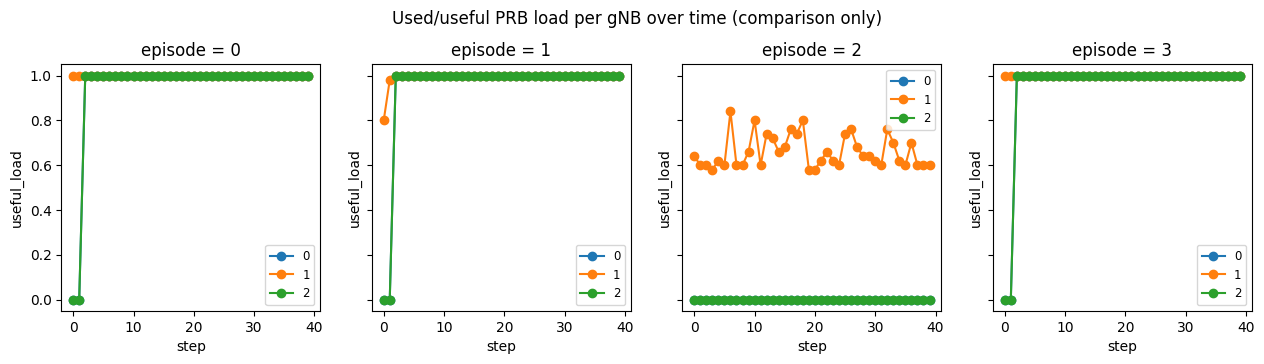

In [21]:
useful_total_cols = [f"useful_load_g{gid}" for gid in GNB_IDS if f"useful_load_g{gid}" in df.columns]
useful_df = df.melt(id_vars=["episode", "step", "scenario_name"], value_vars=useful_total_cols, var_name="gnb", value_name="useful_load")
useful_df["gnb"] = useful_df["gnb"].str.extract(r"g(\d+)").astype(int)
g = sns.relplot(data=useful_df, x="step", y="useful_load", hue="gnb", col="episode", kind="line", marker="o", height=3.2, aspect=1.2, facet_kws={"sharey": True})
g.fig.suptitle("Used/useful PRB load per gNB over time (comparison only)", y=1.05)


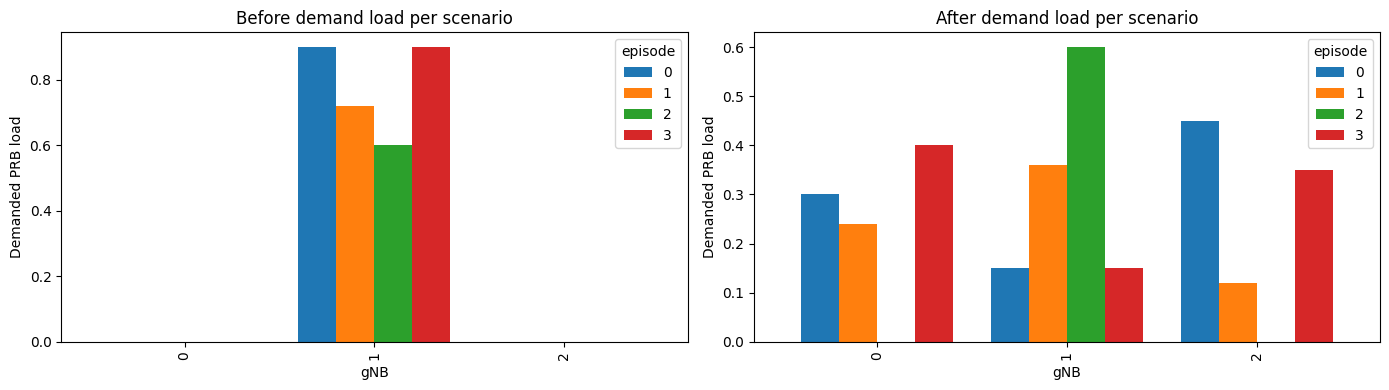

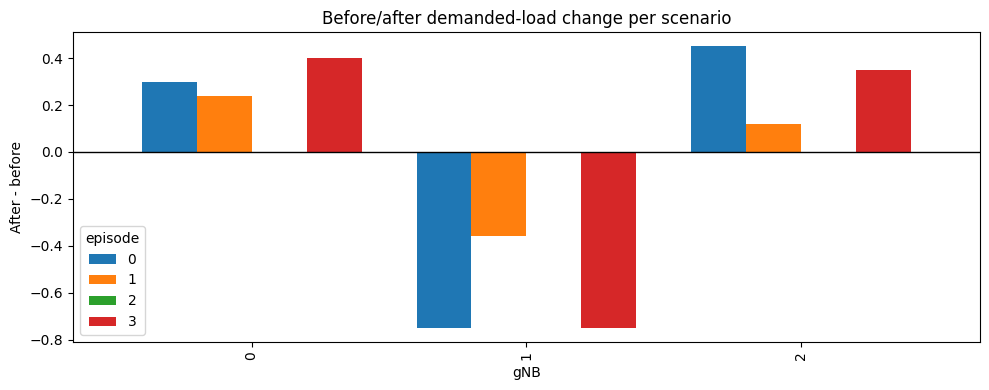

In [22]:
change_rows = []
for (episode, scenario), group in df.groupby(["episode", "scenario_name"], sort=False):
    first, last = group.iloc[0], group.iloc[-1]
    for gid in GNB_IDS:
        col = f"demand_prb_load_g{gid}"
        if col in group.columns:
            change_rows.append({"episode": episode, "scenario_name": scenario, "gnb": gid, "before": float(first[col]), "after": float(last[col]), "change": float(last[col] - first[col])})
change_df = pd.DataFrame(change_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
sns.barplot(data=change_df, x="gnb", y="before", hue="episode", ax=axes[0]); axes[0].set_title("Before demand load per scenario")
sns.barplot(data=change_df, x="gnb", y="after", hue="episode", ax=axes[1]); axes[1].set_title("After demand load per scenario")
for ax in axes: ax.set_xlabel("gNB"); ax.set_ylabel("Demanded PRB load")
plt.tight_layout()
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=change_df, x="gnb", y="change", hue="episode", ax=ax)
ax.axhline(0.0, color="black", linewidth=1); ax.set_title("Before/after demanded-load change per scenario"); ax.set_xlabel("gNB"); ax.set_ylabel("After - before")
plt.tight_layout()


Text(0.5, 1.05, 'Controlled gNB heuristic action offsets')

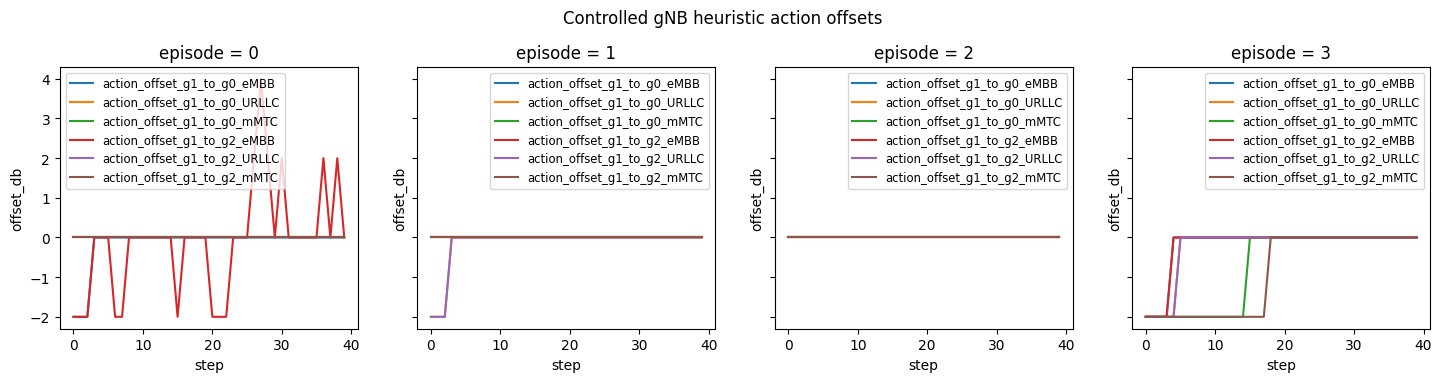

In [23]:
action_cols = [c for c in df.columns if c.startswith(f"action_offset_g{CONFIG['controlled_gnb_id']}_to_g")]
action_df = df.melt(id_vars=["episode", "step", "scenario_name"], value_vars=action_cols, var_name="offset", value_name="offset_db")
g = sns.relplot(data=action_df, x="step", y="offset_db", hue="offset", col="episode", kind="line", height=3.4, aspect=1.3, facet_kws={"sharey": True})
g.fig.suptitle("Controlled gNB heuristic action offsets", y=1.05)


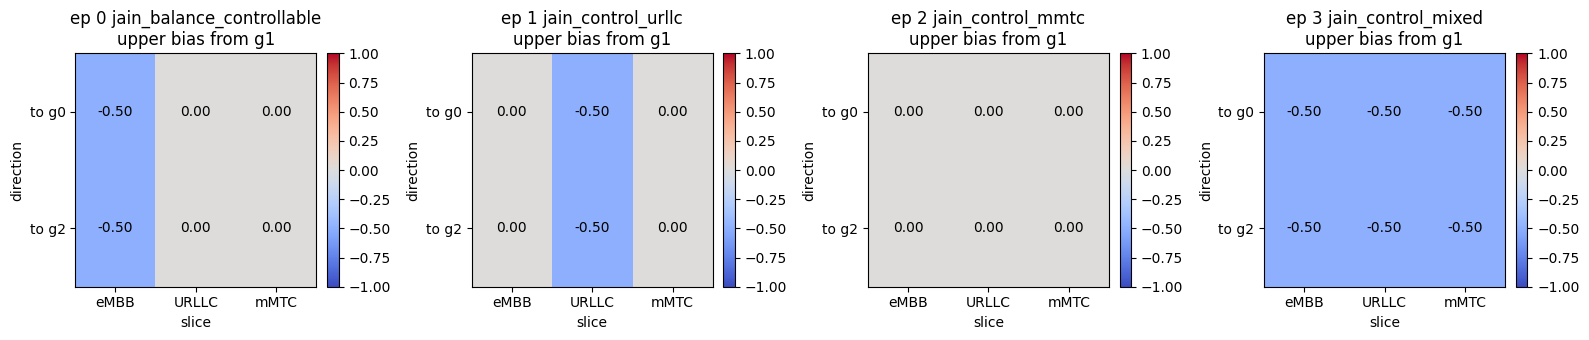

In [24]:
def _bias_matrix_from_json(bias_json, env, source_gnb=None):
    bias = json.loads(bias_json)
    source_gnb = int(env.controlled_gnb_id if source_gnb is None else source_gnb)
    neighbors = list(env.neighbors[source_gnb])
    mat = np.zeros((len(neighbors), len(env.slice_types)), dtype=float)
    for ni, nb in enumerate(neighbors):
        for si, st in enumerate(env.slice_types):
            mat[ni, si] = float(bias.get(f"{source_gnb}|{nb}|{st}", 0.0))
    return mat, neighbors

sample_rows = df.groupby("episode", sort=False).head(1)
fig, axes = plt.subplots(1, max(len(sample_rows), 1), figsize=(4 * max(len(sample_rows), 1), 3.5), squeeze=False)
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    mat, neighbors = _bias_matrix_from_json(row["upper_bias_json"], env)
    sns.heatmap(mat, annot=True, fmt=".2f", center=0.0, vmin=-1.0, vmax=1.0, cmap="coolwarm", xticklabels=list(env.slice_types), yticklabels=[f"to g{nb}" for nb in neighbors], ax=ax)
    ax.set_title(f"ep {row['episode']} {row['scenario_name']}\nupper bias from g{env.controlled_gnb_id}")
    ax.set_xlabel("slice"); ax.set_ylabel("direction")
plt.tight_layout()


## Close environment


In [25]:
env.close()
